<a href="https://colab.research.google.com/github/KarthikSaravanakumarM56/24ADI003-24BAD056/blob/main/ML_Exp_10_scenario1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

24BAD056 - M.Karthik saravanakumar
SVD RMSE: 2.362034411789045
SVD MAE: 1.978958206886534

Top Recommendations for User 1:
      movieId                              title
507       589  Terminator 2: Judgment Day (1991)
793      1036                    Die Hard (1988)
902      1200                      Aliens (1986)
1445     1968         Breakfast Club, The (1985)
2078     2762            Sixth Sense, The (1999)


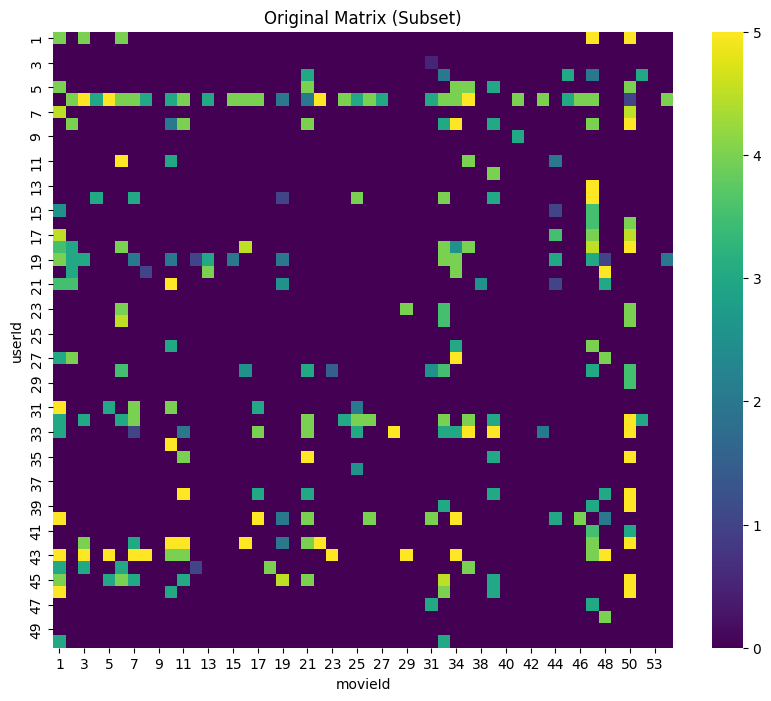

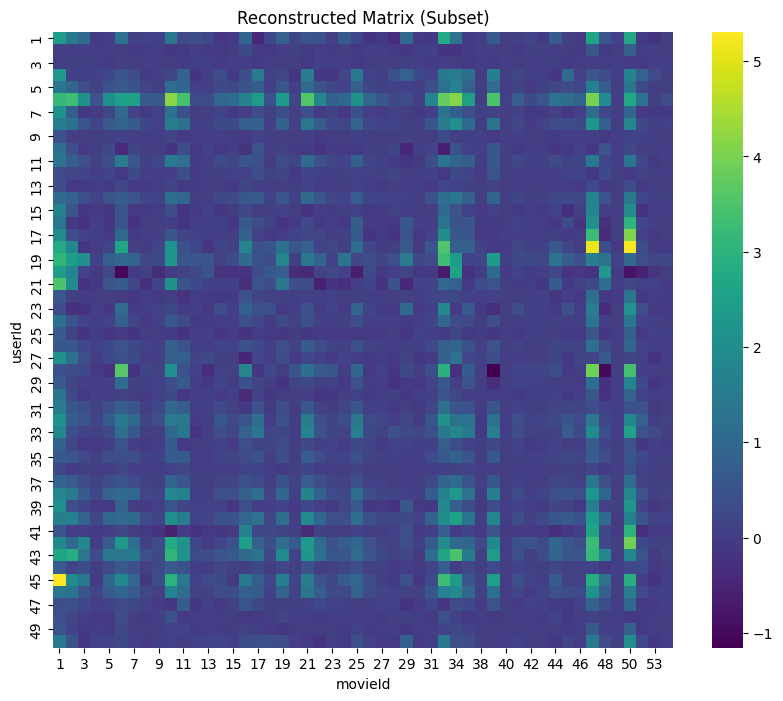

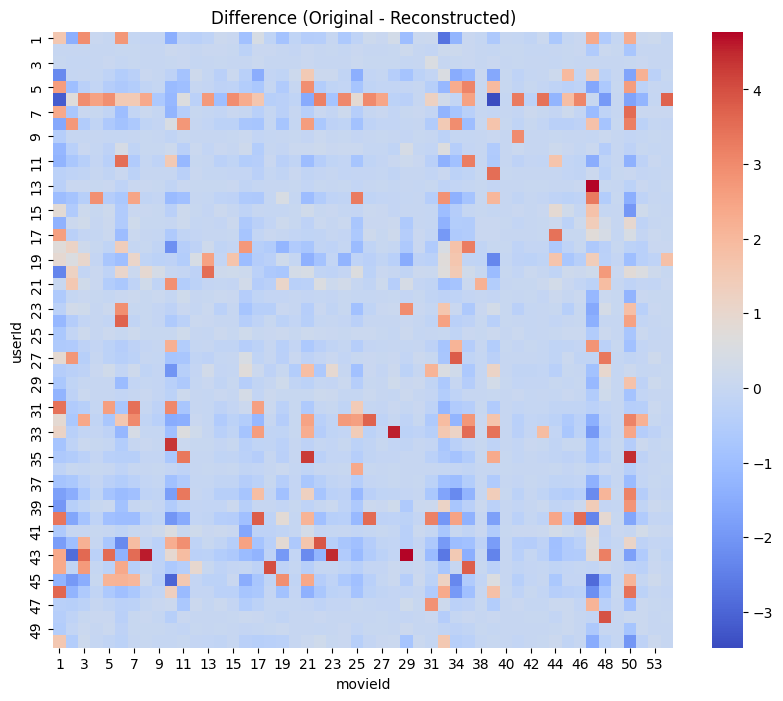

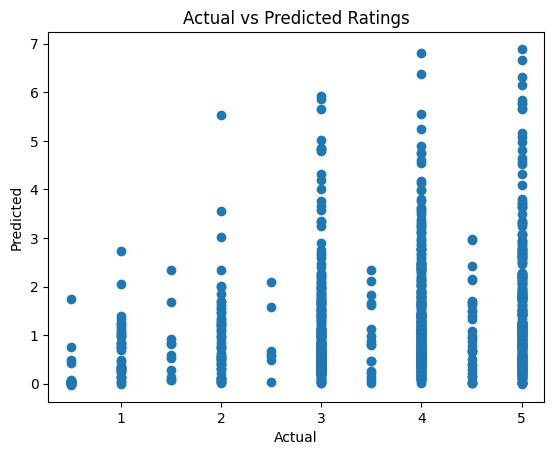

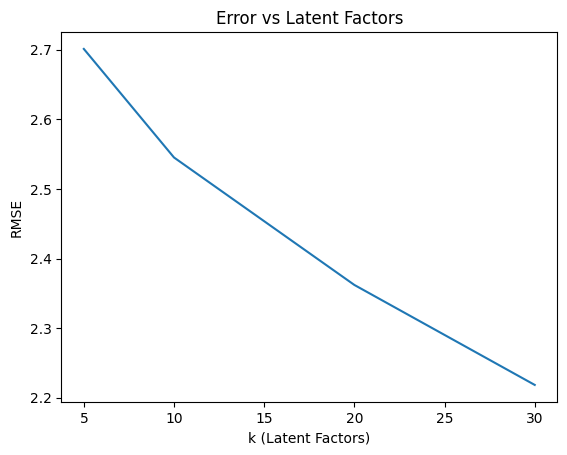

In [2]:
print("24BAD056 - M.Karthik saravanakumar")
# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 2. LOAD DATASET
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')
ratings = ratings.drop('timestamp', axis=1)

# 3. USER-ITEM MATRIX
user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')
matrix_filled = user_item_matrix.fillna(0)

# 4. NORMALIZATION
user_mean = matrix_filled.mean(axis=1)
matrix_norm = matrix_filled.sub(user_mean, axis=0)

# 5. APPLY SVD
U, sigma, Vt = np.linalg.svd(matrix_norm, full_matrices=False)

k = 20
U_k = U[:, :k]
sigma_k = np.diag(sigma[:k])
Vt_k = Vt[:k, :]

# 6. RECONSTRUCTION
reconstructed = np.dot(np.dot(U_k, sigma_k), Vt_k)
reconstructed += user_mean.values.reshape(-1, 1)

pred_svd = pd.DataFrame(reconstructed,
                        index=user_item_matrix.index,
                        columns=user_item_matrix.columns)

# 7. EVALUATION
actual = user_item_matrix.values[user_item_matrix.notna()]
predicted = pred_svd.values[user_item_matrix.notna()]

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("SVD RMSE:", rmse)
print("SVD MAE:", mae)

# 8. RECOMMENDATIONS
def recommend_svd(user_id, n=5):
    user_row = pred_svd.loc[user_id]
    already_rated = user_item_matrix.loc[user_id].dropna().index
    recs = user_row.drop(already_rated).sort_values(ascending=False).head(n)
    return movies[movies['movieId'].isin(recs.index)][['movieId', 'title']]

print("\nTop Recommendations for User 1:")
print(recommend_svd(1))

# 9. VISUALIZATION
subset_original = user_item_matrix.fillna(0).iloc[:50, :50]
subset_reconstructed = pred_svd.iloc[:50, :50]

plt.figure(figsize=(10, 8))
sns.heatmap(subset_original, cmap='viridis')
plt.title("Original Matrix (Subset)")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(subset_reconstructed, cmap='viridis')
plt.title("Reconstructed Matrix (Subset)")
plt.show()

difference = subset_original - subset_reconstructed

plt.figure(figsize=(10, 8))
sns.heatmap(difference, cmap='coolwarm')
plt.title("Difference (Original - Reconstructed)")
plt.show()

plt.figure()
plt.scatter(actual[:1000], predicted[:1000])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Ratings")
plt.show()

k_values = [5, 10, 20, 30]
errors = []

for k in k_values:
    U_k = U[:, :k]
    sigma_k = np.diag(sigma[:k])
    Vt_k = Vt[:k, :]

    recon = np.dot(np.dot(U_k, sigma_k), Vt_k)
    recon += user_mean.values.reshape(-1, 1)

    pred = recon[user_item_matrix.notna()]
    err = np.sqrt(mean_squared_error(actual, pred))
    errors.append(err)

plt.figure()
plt.plot(k_values, errors)
plt.xlabel("k (Latent Factors)")
plt.ylabel("RMSE")
plt.title("Error vs Latent Factors")
plt.show()